# **Fase 3.1 — Agrupamento de Dados: Análise das Notas do ENEM**

Nesta terceira etapa, daremos continuidade à análise avançando para a aplicação de métodos de agrupamento (clustering). O objetivo será identificar padrões e perfis entre os candidatos do ENEM a partir das variáveis selecionadas, considerando tanto aspectos socioeconômicos quanto de desempenho. Para isso, partiremos da base já limpa e padronizada, aplicaremos técnicas de normalização quando necessário e utilizaremos algoritmos de agrupamento, como o k-means, de forma a organizar os candidatos em grupos com características semelhantes. Em seguida, avaliaremos a qualidade desses agrupamentos por meio de métricas como o coeficiente de silhueta, permitindo interpretar os resultados e destacar perfis relevantes que auxiliem na compreensão do contexto educacional da região de abrangência do IFNMG.

Importando as bibliotecas que serão utilizadas.

In [1]:
import os
import re
import pandas as pd
import numpy as np
import scipy.stats
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from matplotlib.ticker import FuncFormatter
from kmodes.kmodes import KModes
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.metrics import confusion_matrix

### **Realizando a leitura da base de área de MG**

In [2]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **Filtrando a área de abrangencia do IFNMG**

In [3]:
cidades_filtro = [
    "Almenara","Alvorada de Minas","Angelândia","Araçuaí","Aricanduva","Arinos","Ataléia",
    "Augusto de Lima","Bandeira","Berilo","Berizal","Bertópolis","Bocaiúva","Bonfinópolis de Minas",
    "Bonito de Minas","Botumirim","Brasília de Minas","Buenópolis","Buritis","Buritizeiro","Cabeceira Grande",
    "Cachoeira de Pajeú","Campanário","Campo Azul","Capelinha","Capitão Enéas","Caraí","Carbonita",
    "Carlos Chagas","Catuji","Catuti","Chapada Gaúcha","Chapada do Norte","Claro dos Poções","Comercinho",
    "Coração de Jesus","Corinto","Coronel Murta","Couto de Magalhães de Minas","Cristália","Crisólita",
    "Curral de Dentro","Curvelo","Cônego Marinho","Datas","Diamantina","Divisa Alegre","Divisópolis",
    "Dom Bosco","Engenheiro Navarro","Espinosa","Felisburgo","Felixlândia","Felício dos Santos","Formoso",
    "Francisco Badaró","Francisco Dumont","Francisco Sá","Franciscópolis","Frei Gaspar","Fronteira dos Vales",
    "Fruta de Leite","Gameleiras","Glaucilândia","Gouveia","Grão Mogol","Guaraciama","Ibiaí","Ibiracatu",
    "Icaraí de Minas","Indaiabira","Inimutaba","Itacambira","Itacarambi","Itaipé","Itamarandiba","Itambacuri",
    "Itaobim","Itinga","Jacinto","Janaúba","Januária","Japonvar","Jaíba","Jenipapo de Minas","Jequitaí",
    "Jequitinhonha","Joaquim Felício","Joaíma","Jordânia","Josenópolis","José Gonçalves de Minas","Juramento",
    "Juvenília","Ladainha","Lagoa dos Patos","Lassance","Leme do Prado","Lontra","Luislândia","Machacalis",
    "Malacacheta","Mamonas","Manga","Mata Verde","Matias Cardoso","Mato Verde","Medina","Minas Novas",
    "Mirabela","Miravânia","Monjolos","Montalvânia","Monte Azul","Monte Formoso","Montes Claros","Montezuma",
    "Morro da Garça","Nanuque","Natalândia","Ninheira","Nova Módica","Nova Porteirinha","Novo Cruzeiro",
    "Novo Oriente de Minas","Novorizonte","Olhos-d'Água","Ouro Verde de Minas","Padre Carvalho","Padre Paraíso",
    "Pai Pedro","Palmópolis","Patis","Pavão","Pedra Azul","Pedras de Maria da Cruz","Pescador","Pintópolis",
    "Pirapora","Ponto Chique","Ponto dos Volantes","Porteirinha","Poté","Presidente Juscelino",
    "Presidente Kubitschek","Riachinho","Riacho dos Machados","Rio Pardo de Minas","Rio do Prado","Rubelita",
    "Rubim","Salinas","Salto da Divisa","Santa Cruz de Salinas","Santa Fé de Minas","Santa Helena de Minas",
    "Santa Maria do Salto","Santo Antônio do Itambé","Santo Antônio do Jacinto","Santo Antônio do Retiro",
    "Santo Hipólito","Senador Modestino Gonçalves","Serra Azul de Minas","Serra dos Aimorés","Serranópolis de Minas",
    "Serro","Setubinha","São Francisco","São Gonçalo do Rio Preto","São José do Divino","São João da Lagoa",
    "São João da Ponte","São João das Missões","São João do Pacuí","São João do Paraíso","São Romão","Taiobeiras",
    "Teófilo Otoni","Três Marias","Turmalina","Ubaí","Umburatiba","Unaí","Uruana de Minas","Urucuia",
    "Vargem Grande do Rio Pardo","Varzelândia","Verdelândia","Veredinha","Virgem da Lapa","Várzea da Palma",
    "Água Boa","Águas Formosas","Águas Vermelhas"
]
df_ifnmg = df_final[(df_final['NO_MUNICIPIO_ESC'].isin(cidades_filtro))]
df_ifnmg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
6,2018,2,M,0.0,3,1,2,2,1.0,Chapada do Norte,...,B,A,A,C,B,A,C,A,B,B
9,2018,3,F,0.0,1,1,2,2,1.0,Teófilo Otoni,...,B,A,A,B,A,B,E,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,A,B,E,A,C,B
517781,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,A,A,A,B,A,A,B,A,A,B
517789,2023,4,M,1.0,1,1,2,2,NaN,Teófilo Otoni,...,B,A,A,A,A,A,D,A,A,B
517799,2023,2,M,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,B,A,E,B,C,B


### **Aplicando o StandardScaler**

A função normaliza os dados transformando-os para que tenham média 0 e desvio padrão 1. Isso é útil para algoritmos de aprendizado de máquina que são sensíveis à escala das variáveis.

In [4]:
df_scaler = df_ifnmg.copy()

colunas_para_escalar = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]

scaler = StandardScaler()
df_scaler[colunas_para_escalar] = scaler.fit_transform(df_scaler[colunas_para_escalar])

df_scaler

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
6,2018,2,M,0.0,3,1,2,2,1.0,Chapada do Norte,...,B,A,A,C,B,A,C,A,B,B
9,2018,3,F,0.0,1,1,2,2,1.0,Teófilo Otoni,...,B,A,A,B,A,B,E,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517770,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,A,B,E,A,C,B
517781,2023,3,F,1.0,3,1,2,2,1.0,Montes Claros,...,A,A,A,B,A,A,B,A,A,B
517789,2023,4,M,1.0,1,1,2,2,NaN,Teófilo Otoni,...,B,A,A,A,A,A,D,A,A,B
517799,2023,2,M,1.0,3,1,2,2,1.0,Montes Claros,...,B,A,B,B,B,A,E,B,C,B


## **Agrupamento de Dados**

Nesta seção, são apresentados os principais resultados do Agrupamento de Dados aplicados à base do ENEM, com foco nos candidatos da área de abrangência do IFNMG. O objetivo das análises foi compreender o perfil socioeconômico dos participantes, considerando aspectos como escolaridade dos pais, renda familiar e acesso a bens e serviços.

## **Normalizando as notas e calculando o k só com as notas.**
Para definir o número ideal de clusters (k) no algoritmo K-Means, utilizaremos dois métodos complementares: o método do cotovelo e o método da silhueta.

O **método do cotovelo** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula a soma dos erros quadráticos dentro dos clusters (inertia) para diferentes valores de k. O ponto em que a redução do erro começa a diminuir de forma menos acentuada — formando um “cotovelo” no gráfico — indica o valor ideal de k.

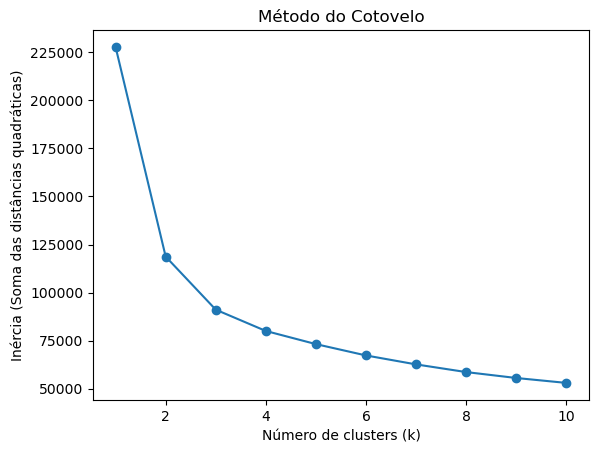

In [5]:
df_notas = df_ifnmg.copy()
notas = df_notas[["NU_NOTA_CN",	"NU_NOTA_CH",	"NU_NOTA_LC", "NU_NOTA_MT"]]

# Remover linhas com NaN nas colunas de notas
notas = notas.dropna()

# Normalizar
scaler = StandardScaler()
notas_normalizadas = scaler.fit_transform(notas)

# Testar diferentes valores de k
inercia = []
K = range(1, 11)  # de 1 a 10 clusters

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(notas_normalizadas)
    inercia.append(kmeans.inertia_)

# Plotar o gráfico do cotovelo
plt.plot(K, inercia, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia (Soma das distâncias quadráticas)")
plt.title("Método do Cotovelo")
plt.show()

O **método da silhueta** é utilizado para identificar o número ideal de clusters (k) no K-Means. Ele calcula o coeficiente de silhueta para cada ponto, que mede o quão próximo ele está de pontos do mesmo cluster em comparação com pontos de outros clusters. Valores de silhueta próximos de 1 indicam que o ponto está bem classificado e valores próximos de 0 indicam sobreposição entre clusters.

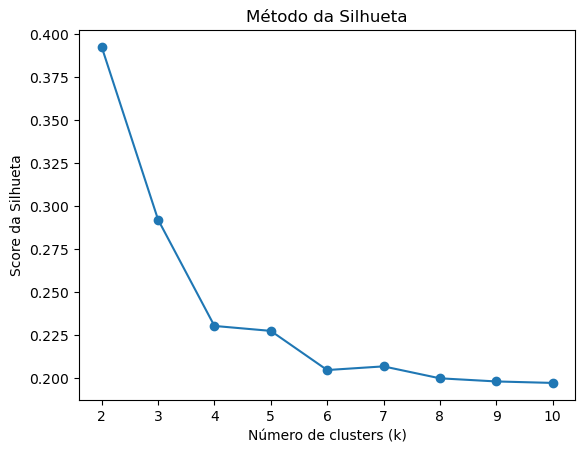

In [6]:
# Calcular os scores de silhueta para diferentes k
silhueta_scores = []
K = range(2, 11)  # começa do 2 porque silhueta não faz sentido para k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(notas_normalizadas)
    score = silhouette_score(notas_normalizadas, labels)
    silhueta_scores.append(score)

# Plotar gráfico da silhueta
plt.plot(K, silhueta_scores, marker="o")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Score da Silhueta")
plt.title("Método da Silhueta")
plt.show()

## **Avaliação Interna do Agrupamento e Silhueta para todos os clusters**
Para avaliar a qualidade dos agrupamentos obtidos, foram utilizadas duas métricas internas: (a) a Soma das Distâncias Quadradas aos Centróides (SSQ), que mede a compacidade dos clusters, e (b) a Razão entre Distância Intracluster e Intercluster (Intra/Inter), que avalia simultaneamente a coesão interna e a separação entre grupos.

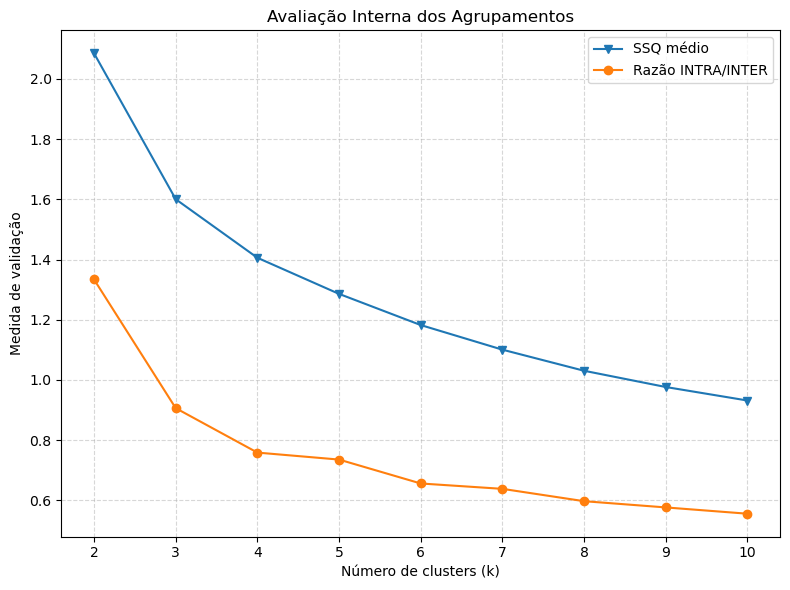


Silhueta global (k=3): 0.2921

Silhueta por cluster:
                      N     media   mediana    desvio    minimo    maximo
Cluster                                                                  
Desempenho Baixo  20496  0.302688  0.332461  0.143109 -0.011209  0.515058
Desempenho Médio  23348  0.238306  0.248096  0.127395 -0.043520  0.495975
Desempenho Alto   13102  0.371353  0.422200  0.157642  0.001742  0.576733


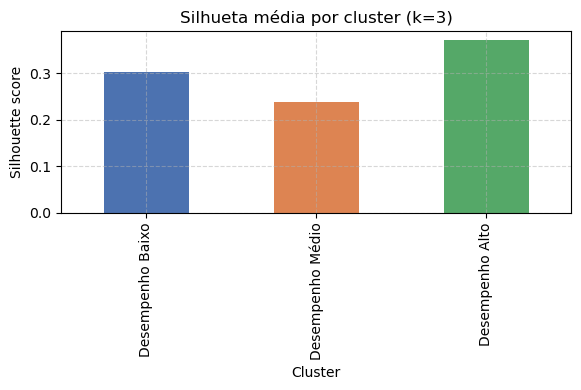

In [7]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = df_notas[colunas_notas].dropna().copy()

# Normalização das notas
scaler = StandardScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(notas),
    columns=colunas_notas,
    index=notas.index
)


# ============================================================
# 2️⃣ Avaliação Interna (SSQ e INTRA/INTER)
# ============================================================
K = range(2, 11)
ssq_values = []
intra_inter_values = []

for k in K:
    kmeans_tmp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    labels_tmp = kmeans_tmp.fit_predict(df_norm)

    # SSQ médio
    ssq = kmeans_tmp.inertia_ / len(df_norm)
    ssq_values.append(ssq)

    # Distâncias intra-cluster
    intra_dists = []
    for lbl in np.unique(labels_tmp):
        cluster_points = df_norm[labels_tmp == lbl]
        if len(cluster_points) > 2:
            sample = cluster_points.sample(
                n=min(500, len(cluster_points)),
                random_state=42
            )
            intra = np.mean(pairwise_distances(sample))
        else:
            intra = 0
        intra_dists.append(intra)

    intra_mean = np.mean(intra_dists)

    # Distâncias inter-cluster
    centers = kmeans_tmp.cluster_centers_
    inter_mean = np.mean(pairwise_distances(centers))

    intra_inter_values.append(intra_mean / inter_mean)


# ----------------------------
# Gráfico - Avaliação Interna
# ----------------------------
plt.figure(figsize=(8, 6))
plt.plot(K, ssq_values, 'v-', label='SSQ médio')
plt.plot(K, intra_inter_values, 'o-', label='Razão INTRA/INTER')
plt.xlabel("Número de clusters (k)")
plt.ylabel("Medida de validação")
plt.title("Avaliação Interna dos Agrupamentos")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# ============================================================
# 3️⃣ Modelo Final (k = 3)
# ============================================================
k_final = 3

kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

labels_final = kmeans_final.fit_predict(df_norm)


# ============================================================
# 4️⃣ Renomeação Semântica dos Clusters
# ============================================================
centers = kmeans_final.cluster_centers_
order = centers.mean(axis=1).argsort()  # pior → melhor

old2rank = {old: i for i, old in enumerate(order)}

rank2name = {
    0: "Desempenho Baixo",
    1: "Desempenho Médio",
    2: "Desempenho Alto"
}


# ============================================================
# 5️⃣ Análise de Silhueta
# ============================================================
sil_global = silhouette_score(df_norm, labels_final)
sil_samples = silhouette_samples(df_norm, labels_final)

df_sil = pd.DataFrame({
    "cluster_id": labels_final,
    "sil": sil_samples
})

df_sil["rank"] = df_sil["cluster_id"].map(old2rank)
df_sil["Cluster"] = df_sil["rank"].map(rank2name)


# ============================================================
# 6️⃣ Resumo Estatístico da Silhueta por Cluster
# ============================================================
resumo = (
    df_sil
    .groupby(["rank", "Cluster"])["sil"]
    .agg(
        N="count",
        media="mean",
        mediana="median",
        desvio="std",
        minimo="min",
        maximo="max"
    )
    .reset_index()
    .sort_values("rank")
    .drop(columns="rank")
    .set_index("Cluster")
)

print(f"\nSilhueta global (k={k_final}): {sil_global:.4f}\n")
print("Silhueta por cluster:")
print(resumo)


# ============================================================
# 7️⃣ Gráfico - Silhueta Média por Cluster
# ============================================================
plt.figure(figsize=(6, 4))

(
    df_sil
    .groupby("Cluster")["sil"]
    .mean()
    .reindex([
        "Desempenho Baixo",
        "Desempenho Médio",
        "Desempenho Alto"
    ])
    .plot(
        kind="bar",
        color=["#4C72B0", "#DD8452", "#55A868"]
    )
)

plt.title(f"Silhueta média por cluster (k={k_final})")
plt.ylabel("Silhouette score")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()



## **Bisecting K-Means**

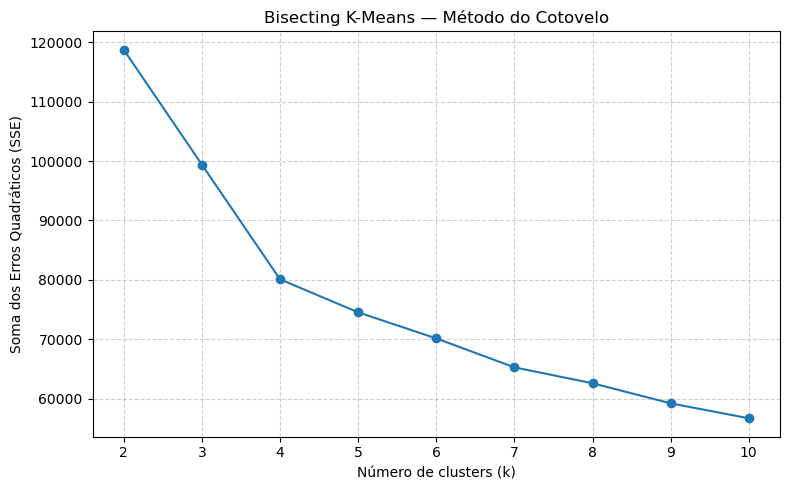


Distribuição final dos clusters (k = 3):

Cluster
Alto     23675
Médio    19420
Baixo    13851
Name: count, dtype: int64


In [8]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = df_notas[colunas_notas].dropna().copy()

# Normalização apenas para clusterização
scaler = StandardScaler()
X = scaler.fit_transform(notas)


# ============================================================
# 2️⃣ Implementação do Bisecting K-Means
# ============================================================
def bisecting_kmeans(X, k_final=3, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)

    while len(clusters) < k_final:
        # SSE de cada cluster atual
        inertias = {}
        for cid, X_cluster in clusters.items():
            if len(X_cluster) > 1:
                km = KMeans(n_clusters=1, random_state=random_state)
                km.fit(X_cluster)
                inertias[cid] = km.inertia_
            else:
                inertias[cid] = 0

        # Cluster com maior SSE
        cluster_to_split = max(inertias, key=inertias.get)
        X_split = clusters[cluster_to_split]

        # Bissecção
        km_split = KMeans(
            n_clusters=2,
            n_init=n_init,
            random_state=random_state
        )
        split_labels = km_split.fit_predict(X_split)

        new_cluster_id = max(clusters.keys()) + 1

        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_cluster_id] = X_split[split_labels == 1]

        # Atualiza labels globais
        idx = np.where(labels == cluster_to_split)[0]
        labels[idx] = np.where(
            split_labels == 0,
            cluster_to_split,
            new_cluster_id
        )

    return labels


# ============================================================
# 3️⃣ Método do Cotovelo (SSE do Bisecting)
# ============================================================
intervalo_k = range(2, 11)
sse_values = []

for k in intervalo_k:
    labels_bis = bisecting_kmeans(X, k_final=k)

    sse_total = 0
    for lbl in np.unique(labels_bis):
        cluster_points = X[labels_bis == lbl]
        if len(cluster_points) > 1:
            center = cluster_points.mean(axis=0)
            sse_total += np.sum((cluster_points - center) ** 2)

    sse_values.append(sse_total)


# ============================================================
# 4️⃣ Gráfico do Cotovelo
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(intervalo_k, sse_values, marker="o")
plt.title("Bisecting K-Means — Método do Cotovelo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Soma dos Erros Quadráticos (SSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


# ============================================================
# 5️⃣ Modelo Final — k = 3 + Renomeação Semântica
# ============================================================
k_final = 3
labels_final = bisecting_kmeans(X, k_final=k_final)

# Ordena clusters pela média (pior → melhor)
centers_mean = []
for lbl in np.unique(labels_final):
    centers_mean.append(X[labels_final == lbl].mean())

order = np.argsort(centers_mean)
old2rank = {old: r for r, old in enumerate(order)}

# 🔹 RÓTULOS CORRETOS PARA k = 3
rank2name = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}

labels_semanticos = np.array(
    [rank2name[old2rank[l]] for l in labels_final]
)

# (Opcional) adiciona ao dataframe
notas_bis = notas.copy()
notas_bis["Cluster"] = labels_semanticos

print("\nDistribuição final dos clusters (k = 3):\n")
print(notas_bis["Cluster"].value_counts())

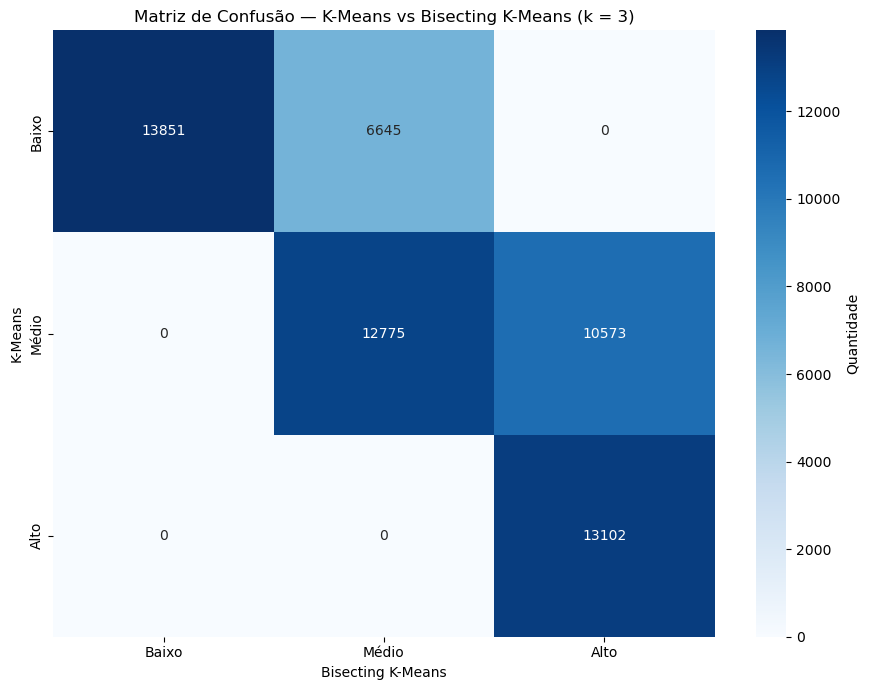

In [9]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = df_notas[colunas_notas].dropna().copy()

# Normalização apenas para clusterização
scaler = StandardScaler()
X = scaler.fit_transform(notas)


# ============================================================
# 2️⃣ Bisecting K-Means
# ============================================================
def bisecting_kmeans(X, k_final=3, n_init=10, random_state=42):
    clusters = {0: X}
    labels = np.zeros(len(X), dtype=int)

    while len(clusters) < k_final:
        inertias = {}
        for cid, X_cluster in clusters.items():
            if len(X_cluster) > 1:
                km = KMeans(n_clusters=1, random_state=random_state)
                km.fit(X_cluster)
                inertias[cid] = km.inertia_
            else:
                inertias[cid] = 0

        cluster_to_split = max(inertias, key=inertias.get)
        X_split = clusters[cluster_to_split]

        km_split = KMeans(
            n_clusters=2,
            n_init=n_init,
            random_state=random_state
        )
        split_labels = km_split.fit_predict(X_split)

        new_cluster_id = max(clusters.keys()) + 1

        clusters[cluster_to_split] = X_split[split_labels == 0]
        clusters[new_cluster_id] = X_split[split_labels == 1]

        idx = np.where(labels == cluster_to_split)[0]
        labels[idx] = np.where(
            split_labels == 0,
            cluster_to_split,
            new_cluster_id
        )

    return labels


# ============================================================
# 3️⃣ Execução dos Modelos (k = 3)
# ============================================================
k = 3

# K-Means tradicional
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
labels_kmeans_raw = kmeans.fit_predict(X)

# Bisecting K-Means
labels_bis_raw = bisecting_kmeans(X, k_final=k)


# ============================================================
# 4️⃣ Renomeação Semântica (IGUAL para os dois métodos)
# ============================================================
def semantic_relabel(X, labels):
    centers = []
    for lbl in np.unique(labels):
        centers.append(X[labels == lbl].mean())
    centers = np.array(centers)

    order = np.argsort(centers)  # pior → melhor
    old2rank = {old: r for r, old in enumerate(order)}

    return np.array([old2rank[l] for l in labels])


labels_kmeans = semantic_relabel(X, labels_kmeans_raw)
labels_bisect = semantic_relabel(X, labels_bis_raw)

# Rótulos CORRETOS para k = 3
cluster_names = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}


# ============================================================
# 5️⃣ Matriz de Confusão (Semântica)
# ============================================================
cm = confusion_matrix(labels_kmeans, labels_bisect)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[cluster_names[i] for i in range(k)],
    yticklabels=[cluster_names[i] for i in range(k)],
    cbar_kws={"label": "Quantidade"}
)

plt.xlabel("Bisecting K-Means")
plt.ylabel("K-Means")
plt.title("Matriz de Confusão — K-Means vs Bisecting K-Means (k = 3)")
plt.tight_layout()
plt.show()

## **Análise dos Clusters**


Médias e desvios por cluster (notas padronizadas):

        NU_NOTA_CN       NU_NOTA_CH       NU_NOTA_LC       NU_NOTA_MT      
              mean   std       mean   std       mean   std       mean   std
Cluster                                                                    
Alto          1.25  0.67       1.12  0.56       1.10  0.57       1.28  0.69
Baixo        -0.78  0.63      -0.94  0.68      -0.94  0.72      -0.75  0.58
Médio        -0.01  0.65       0.19  0.59       0.21  0.54      -0.06  0.67


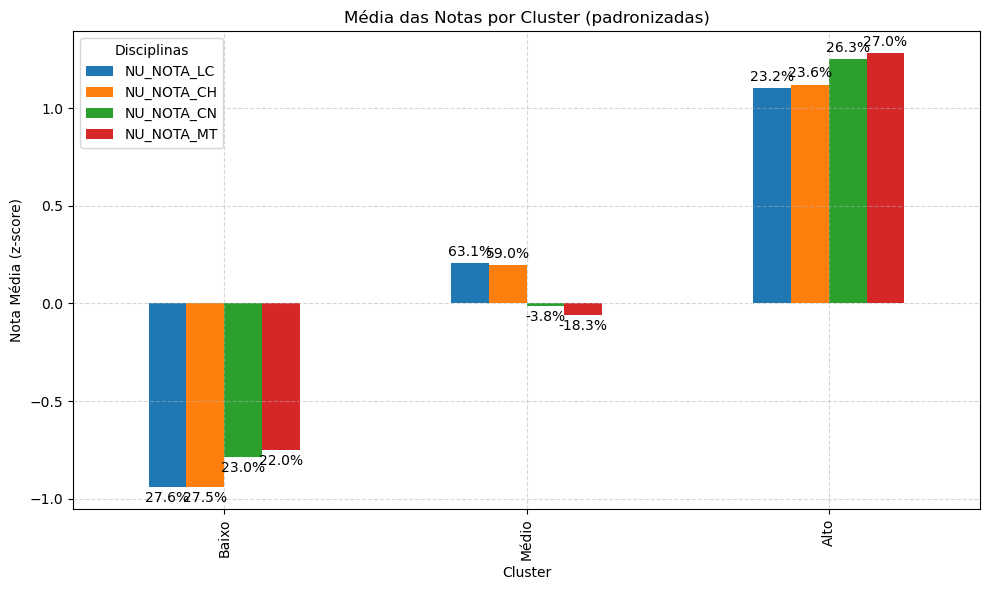

In [10]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
df_notas = df_ifnmg.copy()

colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = df_notas[colunas_notas].dropna().copy()

# Normalização (z-score) — apenas para clusterização e análise padronizada
scaler = StandardScaler()
df_norm = pd.DataFrame(
    scaler.fit_transform(notas),
    index=notas.index,
    columns=colunas_notas
)


# ============================================================
# 2️⃣ K-Means (k = 3)
# ============================================================
k = 3
kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)
labels_raw = kmeans.fit_predict(df_norm)


# ============================================================
# 3️⃣ Renomeação Semântica dos Clusters
# (Baixo → Médio → Alto)
# ============================================================
centers = kmeans.cluster_centers_
centers_mean = centers.mean(axis=1)

order = np.argsort(centers_mean)  # pior → melhor
old2rank = {old: r for r, old in enumerate(order)}

rank2name = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}

df_norm["cluster_id"] = labels_raw
df_norm["Cluster"] = df_norm["cluster_id"].map(old2rank).map(rank2name)


# ============================================================
# 4️⃣ Resumo Estatístico dos Clusters
# ============================================================
resumo_clusters = (
    df_norm
    .groupby("Cluster")[colunas_notas]
    .agg(["mean", "std"])
    .round(2)
)

print("\nMédias e desvios por cluster (notas padronizadas):\n")
print(resumo_clusters)


# ============================================================
# 5️⃣ Gráfico — Médias das Disciplinas por Cluster
# ============================================================
# Ordem lógica dos clusters
ordem_clusters = ["Baixo", "Médio", "Alto"]

resumo_mean = (
    df_norm
    .groupby("Cluster")[colunas_notas]
    .mean()
    .reindex(ordem_clusters)
)

# Ordena disciplinas da menor para a maior média global
ordem_cols = resumo_mean.mean(axis=0).sort_values().index
resumo_sorted = resumo_mean[ordem_cols]

# Percentual de cada disciplina dentro do cluster
percent_df = resumo_sorted.div(resumo_sorted.sum(axis=1), axis=0) * 100


# ----------------------------
# Gráfico
# ----------------------------
ax = resumo_sorted.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Média das Notas por Cluster (padronizadas)")
plt.xlabel("Cluster")
plt.ylabel("Nota Média (z-score)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Disciplinas")

# Percentuais sobre as barras
for i, container in enumerate(ax.containers):
    col = resumo_sorted.columns[i]
    labels = [
        f"{percent_df.loc[cluster, col]:.1f}%"
        for cluster in resumo_sorted.index
    ]
    ax.bar_label(container, labels=labels, padding=3)

plt.tight_layout()
plt.show()

### **Análise dos clusters com as notas sem normalizar**

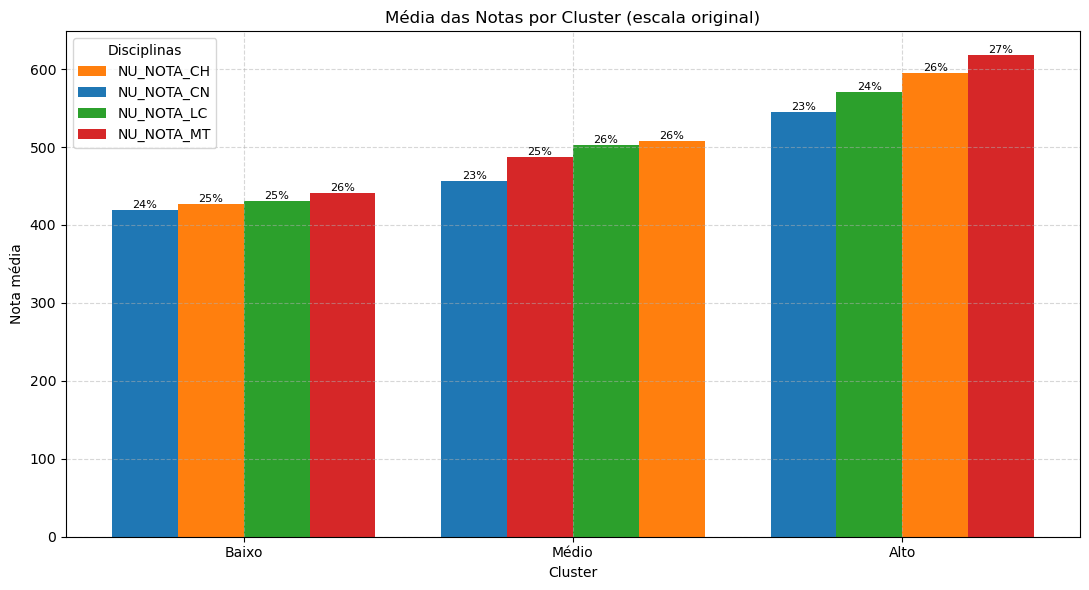

In [11]:
# ============================================================
# 1️⃣ Base com rótulos semânticos (Baixo, Médio, Alto)
# ============================================================
# Assume que:
# - notas contém as notas originais
# - labels_final vem do K-Means k = 3
# - a renomeação semântica já foi definida anteriormente

# 🔹 Renomeação semântica correta para k = 3
centers_mean = (
    notas.groupby(labels_final)[["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]]
    .mean()
    .mean(axis=1)
)

order = centers_mean.sort_values().index.tolist()
old2rank = {old: r for r, old in enumerate(order)}

rank2name = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}

notas_orig = notas.copy()
notas_orig["Cluster"] = [rank2name[old2rank[l]] for l in labels_final]


# ============================================================
# 2️⃣ Média das notas por cluster (escala original)
# ============================================================
colunas_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

resumo_mean = (
    notas_orig
    .groupby("Cluster")[colunas_notas]
    .mean()
    .reindex(["Baixo", "Médio", "Alto"])
)


# ============================================================
# 3️⃣ Formato longo + percentuais internos
# ============================================================
long = (
    resumo_mean
    .reset_index()
    .melt(
        id_vars="Cluster",
        var_name="Disciplina",
        value_name="Valor"
    )
)

# Percentual interno (soma = 100% por cluster)
long["Percent"] = (
    long.groupby("Cluster")["Valor"]
        .transform(lambda s: s / s.sum() * 100)
)

# Ranking das disciplinas dentro do cluster
long["Rank"] = (
    long.groupby("Cluster")["Valor"]
        .rank(method="first", ascending=True)
        .astype(int)
)


# ============================================================
# 4️⃣ Preparação visual
# ============================================================
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
disciplinas = long["Disciplina"].unique().tolist()
cores = {d: palette[i % len(palette)] for i, d in enumerate(disciplinas)}

clusters = ["Baixo", "Médio", "Alto"]
n_vars = len(disciplinas)
width = 0.8 / n_vars

centros = {c: i for i, c in enumerate(clusters)}
offsets = {
    r: (r - (n_vars + 1) / 2) * width
    for r in range(1, n_vars + 1)
}

long["x"] = (
    long["Cluster"].map(centros) +
    long["Rank"].map(offsets)
)


# ============================================================
# 5️⃣ Gráfico final
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))
bar_info = {}

for disc, sub in long.groupby("Disciplina"):
    bars = ax.bar(
        sub["x"],
        sub["Valor"],
        width=width,
        label=disc,
        color=cores[disc]
    )
    bar_info[disc] = (bars, sub)

# Percentuais sobre as barras
for disc, (bars, sub) in bar_info.items():
    for bar, (_, row) in zip(bars, sub.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{row['Percent']:.0f}%",
            ha="center",
            va="bottom",
            fontsize=8
        )

ax.set_xticks(list(centros.values()))
ax.set_xticklabels(clusters)

ax.set_title("Média das Notas por Cluster (escala original)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Nota média")
ax.legend(title="Disciplinas")
ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### **Cenário do desempenho dos inscritos em cada um dos anos contemplados nas bases**

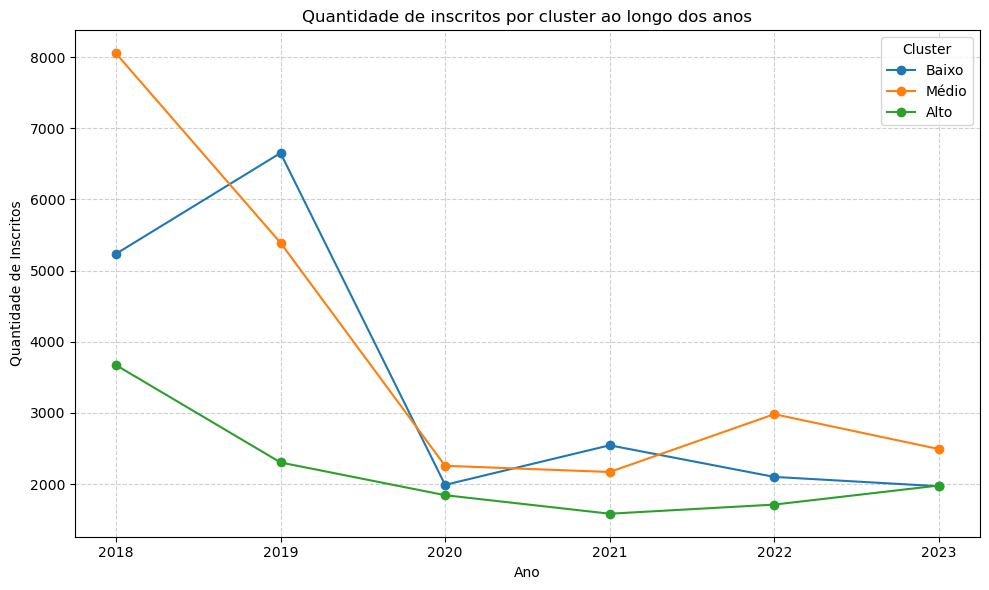

In [12]:
# ============================================================
# 1️⃣ Preparação dos Dados
# ============================================================
colunas_notas = [
    "NU_ANO",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = df_ifnmg[colunas_notas].dropna().copy()

# Apenas as notas (sem média)
X = notas[
    ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
].values


# ============================================================
# 2️⃣ Normalização (somente para clusterização)
# ============================================================
scaler = StandardScaler()
Xz = scaler.fit_transform(X)


# ============================================================
# 3️⃣ K-Means (k = 3)
# ============================================================
k = 3
kmeans_final = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

labels_raw = kmeans_final.fit_predict(Xz)


# ============================================================
# 4️⃣ Renomeação Semântica dos Clusters
# (Baixo → Médio → Alto)
# ============================================================
centers = kmeans_final.cluster_centers_
centers_mean = centers.mean(axis=1)

order = np.argsort(centers_mean)  # pior → melhor
old_to_rank = {old: rank for rank, old in enumerate(order)}

rank_to_name = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}

notas["Cluster"] = [rank_to_name[old_to_rank[l]] for l in labels_raw]


# ============================================================
# 5️⃣ Contagem por Ano e Cluster
# ============================================================
contagem = (
    notas
    .groupby(["NU_ANO", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)


# ============================================================
# 6️⃣ Gráfico — Evolução Temporal
# ============================================================
plt.figure(figsize=(10, 6))

ordem_clusters = ["Baixo", "Médio", "Alto"]

for nome in ordem_clusters:
    df_plot = contagem[contagem["Cluster"] == nome]
    if not df_plot.empty:
        plt.plot(
            df_plot["NU_ANO"],
            df_plot["Quantidade"],
            marker="o",
            label=nome
        )

plt.title("Quantidade de inscritos por cluster ao longo dos anos")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Inscritos")
plt.legend(title="Cluster")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### **Quantidade de inscritos por grupo**

In [13]:
# ============================================================
# 1️⃣ Contagem por Cluster (ordem semântica)
# ============================================================
ordem_clusters = ["Baixo", "Médio", "Alto"]

tabela_clusters = (
    notas["Cluster"]
    .value_counts()
    .reindex(ordem_clusters)
    .reset_index()
)

tabela_clusters.columns = ["Grupo", "Quantidade"]


# ============================================================
# 2️⃣ Total e Percentual
# ============================================================
total = int(tabela_clusters["Quantidade"].sum())

tabela_clusters["Porcentagem"] = (
    tabela_clusters["Quantidade"] / total * 100
).round(1)


# ============================================================
# 3️⃣ Linha Total
# ============================================================
linha_total = pd.DataFrame({
    "Grupo": ["Total"],
    "Quantidade": [total],
    "Porcentagem": [100.0]
})

tabela_final = pd.concat(
    [tabela_clusters, linha_total],
    ignore_index=True
)


# ============================================================
# 4️⃣ Formatação apenas para exibição
# ============================================================
tabela_final_fmt = tabela_final.copy()

tabela_final_fmt["Quantidade"] = (
    tabela_final_fmt["Quantidade"]
    .map(lambda x: f"{int(x):,}".replace(",", "."))
)

tabela_final_fmt["Porcentagem"] = (
    tabela_final_fmt["Porcentagem"]
    .map(lambda x: f"{x:.0f}%")
)


# ============================================================
# 5️⃣ Exibição
# ============================================================
print("\nDistribuição dos participantes por cluster (k = 3):\n")
print(tabela_final_fmt)


Distribuição dos participantes por cluster (k = 3):

   Grupo Quantidade Porcentagem
0  Baixo     20.496         36%
1  Médio     23.348         41%
2   Alto     13.102         23%
3  Total     56.946        100%


### **Quantidade de inscritos por grupo entre 2018 e 2023**

In [14]:
# ============================================================
# 1️⃣ Contagem por Ano e Cluster
# ============================================================
contagem = (
    notas
    .groupby(["NU_ANO", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)


# ============================================================
# 2️⃣ Pivot (ordem semântica correta)
# ============================================================
ordem_clusters = ["Baixo", "Médio", "Alto"]

tabela = (
    contagem
    .pivot(index="NU_ANO", columns="Cluster", values="Quantidade")
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
    .sort_index()
)


# ============================================================
# 3️⃣ Adiciona Total por Ano
# ============================================================
tabela_fmt = tabela.copy()
tabela_fmt["Total"] = tabela_fmt.sum(axis=1)


# ============================================================
# 4️⃣ Formatação para Exibição
# ============================================================
tabela_fmt = tabela_fmt.applymap(
    lambda x: f"{int(x):,}".replace(",", ".")
)


# ============================================================
# 5️⃣ Exibição
# ============================================================
print("\nQuantidade de inscritos por ano e cluster (k = 3):\n")
print(tabela_fmt)


Quantidade de inscritos por ano e cluster (k = 3):

Cluster  Baixo  Médio   Alto   Total
NU_ANO                              
2018     5.235  8.052  3.673  16.960
2019     6.652  5.391  2.305  14.348
2020     1.990  2.258  1.845   6.093
2021     2.546  2.171  1.585   6.302
2022     2.102  2.983  1.713   6.798
2023     1.971  2.493  1.981   6.445


C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_31784\3253151757.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabela_fmt = tabela_fmt.applymap(


### **Média e Desvio Padrão das notas por grupo entre 2018 e 2023**

In [15]:
# ============================================================
# 1️⃣ Configurações
# ============================================================
cols_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

ordem_clusters = ["Baixo", "Médio", "Alto"]


# ============================================================
# 2️⃣ Agregação — média das notas
# ============================================================
agg = (
    notas[notas["Cluster"].isin(ordem_clusters)]
    .groupby(["NU_ANO", "Cluster"])[cols_notas]
    .mean()
    .round(1)
    .reset_index()
)


# ============================================================
# 3️⃣ Pivot para formato largo
# ============================================================
wide = (
    agg
    .pivot(index="NU_ANO", columns="Cluster", values=cols_notas)
    .reindex(
        columns=pd.MultiIndex.from_product([cols_notas, ordem_clusters])
    )
    .sort_index()
)


# ============================================================
# 4️⃣ Abreviações das disciplinas
# ============================================================
abrevs = {
    "NU_NOTA_CN": "Ciên. Nat.",
    "NU_NOTA_CH": "Ciên. Hum.",
    "NU_NOTA_LC": "Linguagens",
    "NU_NOTA_MT": "Matemática"
}

def rotulo(col):
    disciplina, cluster = col
    return f"{abrevs[disciplina]} - {cluster}"

wide.columns = [rotulo(c) for c in wide.columns]
wide.index.name = "Ano"


# ============================================================
# 5️⃣ Formatação (vírgula decimal)
# ============================================================
tabela_fmt = wide.copy().applymap(
    lambda x: "" if pd.isna(x) else str(x).replace(".", ",")
)


# ============================================================
# 6️⃣ Exibição
# ============================================================
print("\nMédia das notas por disciplina, ano e cluster (k = 3):\n")
print(tabela_fmt)


Média das notas por disciplina, ano e cluster (k = 3):

     Ciên. Nat. - Baixo Ciên. Nat. - Médio Ciên. Nat. - Alto  \
Ano                                                            
2018              433,6              477,3             571,9   
2019              414,7              479,6             571,3   
2020              425,4              488,6             582,9   
2021              428,7              491,0             586,4   
2022              439,2              487,1             573,3   
2023              425,8              493,7             582,8   

     Ciên. Hum. - Baixo Ciên. Hum. - Médio Ciên. Hum. - Alto  \
Ano                                                            
2018              476,4              564,2             641,8   
2019              431,3              524,1             600,8   
2020              424,9              526,5             619,9   
2021              434,3              536,0             625,5   
2022              450,4              533,2    

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_31784\1027764781.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  tabela_fmt = wide.copy().applymap(


### **Quantidade de inscritos por grupo para cada tipo de escola**

C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_31784\3846269577.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ifnmg["TP_ESCOLA_PAD"] = df_ifnmg.apply(padronizar_tp_escola, axis=1)



📊 Tabela Tipo de Escola x Grupo de Desempenho:



Cluster,Baixo,Médio,Alto
TP_ESCOLA_PAD,,,
Não Informado,35,225,469
Pública,19906,21257,8654
Privada,548,1863,3976
Exterior,7,3,3


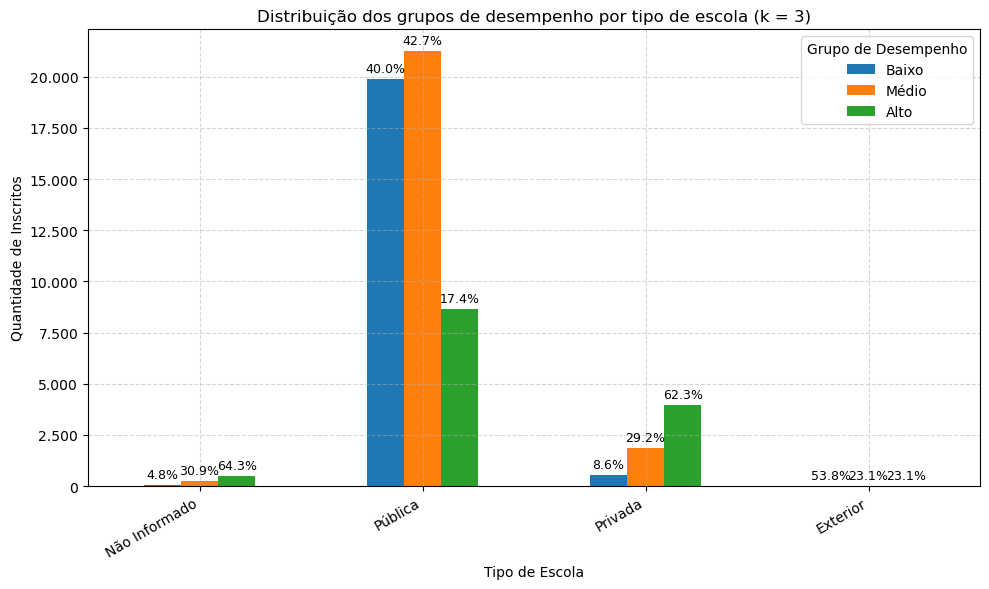

In [17]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from matplotlib.ticker import FuncFormatter


# ============================================================
# 1️⃣ PADRONIZAÇÃO DE TP_ESCOLA
# ============================================================

def padronizar_tp_escola(row):
    ano = row["NU_ANO"]
    valor = row["TP_ESCOLA"]

    if pd.isna(valor):
        return "Não Informado"

    # 2018
    if ano == 2018:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            4: "Privada",
            3: "Exterior"
        }

    # 2019 e 2020
    elif ano in [2019, 2020]:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            3: "Privada",
            4: "Exterior"
        }

    # 2021+
    elif ano in [2021, 2022, 2023]:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            3: "Privada"
        }

    else:
        return "Não Informado"

    return mapa.get(valor, "Não Informado")


# Aplicar padronização no df_ifnmg
df_ifnmg["TP_ESCOLA_PAD"] = df_ifnmg.apply(padronizar_tp_escola, axis=1)


# ============================================================
# 2️⃣ PREPARAÇÃO DA BASE PARA CLUSTER
# ============================================================

cols = [
    "TP_ESCOLA_PAD",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

base = df_ifnmg[cols].dropna().copy()

ordem_escola = ["Não Informado", "Pública", "Privada", "Exterior"]

base["TP_ESCOLA_PAD"] = pd.Categorical(
    base["TP_ESCOLA_PAD"],
    categories=ordem_escola,
    ordered=True
)


# ============================================================
# 3️⃣ CLUSTERIZAÇÃO (k = 3)
# ============================================================

X = base[
    ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
].values

Xz = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    n_init=10,
    random_state=42
)

labels_raw = kmeans.fit_predict(Xz)


# ============================================================
# 4️⃣ RENOMEAÇÃO SEMÂNTICA DOS CLUSTERS
# ============================================================

centers = kmeans.cluster_centers_
centers_mean = centers.mean(axis=1)

order = np.argsort(centers_mean)  # pior → melhor
old2rank = {old: r for r, old in enumerate(order)}

rank2name = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}

base["Cluster"] = pd.Categorical(
    [rank2name[old2rank[l]] for l in labels_raw],
    categories=["Baixo", "Médio", "Alto"],
    ordered=True
)


# ============================================================
# 5️⃣ TABELA TIPO DE ESCOLA × CLUSTER
# ============================================================

contagem = (
    base
    .groupby(["TP_ESCOLA_PAD", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

tabela = (
    contagem
    .pivot_table(
        index="TP_ESCOLA_PAD",
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum",
        observed=True
    )
    .reindex(index=ordem_escola, columns=["Baixo", "Médio", "Alto"])
    .fillna(0)
    .astype(int)
)

percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


print("\n📊 Tabela Tipo de Escola x Grupo de Desempenho:\n")
display(tabela)


# ============================================================
# 6️⃣ GRÁFICO
# ============================================================

ax = tabela.plot(kind="bar", figsize=(10, 6))

ax.set_title("Distribuição dos grupos de desempenho por tipo de escola (k = 3)")
ax.set_xlabel("Tipo de Escola")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo de Desempenho")
ax.grid(True, linestyle="--", alpha=0.5)

plt.xticks(rotation=30, ha="right")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

# Percentuais sobre barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


In [18]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ============================================================
# 1️⃣ PADRONIZAÇÃO TP_ESCOLA
# ============================================================

def padronizar_tp_escola(row):
    ano = row["NU_ANO"]
    valor = row["TP_ESCOLA"]

    if pd.isna(valor):
        return "Não Informado"

    if ano == 2018:
        mapa = {1: "Não Informado", 2: "Pública", 4: "Privada", 3: "Exterior"}
    elif ano in [2019, 2020]:
        mapa = {1: "Não Informado", 2: "Pública", 3: "Privada", 4: "Exterior"}
    elif ano in [2021, 2022, 2023]:
        mapa = {1: "Não Informado", 2: "Pública", 3: "Privada"}
    else:
        return "Não Informado"

    return mapa.get(valor, "Não Informado")


df_ifnmg["TP_ESCOLA_PAD"] = df_ifnmg.apply(padronizar_tp_escola, axis=1)


# ============================================================
# 2️⃣ PREPARAR BASE
# ============================================================

cols = [
    "NU_ANO",
    "TP_ESCOLA_PAD",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

base = df_ifnmg[cols].dropna().copy()

ordem_escola = ["Não Informado", "Pública", "Privada", "Exterior"]

base["TP_ESCOLA_PAD"] = pd.Categorical(
    base["TP_ESCOLA_PAD"],
    categories=ordem_escola,
    ordered=True
)


# ============================================================
# 3️⃣ CLUSTERIZAÇÃO GLOBAL (k=3)
# ============================================================

X = base[["NU_NOTA_CN","NU_NOTA_CH","NU_NOTA_LC","NU_NOTA_MT"]].values

Xz = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)

labels_raw = kmeans.fit_predict(Xz)

# Ordenar semanticamente
centers_mean = kmeans.cluster_centers_.mean(axis=1)
order = np.argsort(centers_mean)
old2rank = {old: r for r, old in enumerate(order)}

rank2name = {0: "Baixo", 1: "Médio", 2: "Alto"}

base["Cluster"] = [
    rank2name[old2rank[l]] for l in labels_raw
]


# ============================================================
# 4️⃣ TABELA POR ANO
# ============================================================

tabela_ano = (
    base
    .groupby(["NU_ANO", "TP_ESCOLA_PAD", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)

tabela_pivot = (
    tabela_ano
    .pivot_table(
        index=["NU_ANO", "TP_ESCOLA_PAD"],
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum"
    )
    .reindex(columns=["Baixo", "Médio", "Alto"])
    .fillna(0)
    .astype(int)
)

print("\n📊 Distribuição por Ano × Tipo de Escola × Cluster:\n")
display(tabela_pivot)


C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_31784\2348857103.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ifnmg["TP_ESCOLA_PAD"] = df_ifnmg.apply(padronizar_tp_escola, axis=1)
C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_31784\2348857103.py:92: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["NU_ANO", "TP_ESCOLA_PAD", "Cluster"])
C:\Users\fernanda.leal\AppData\Local\Temp\ipykernel_31784\2348857103.py:99: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of p


📊 Distribuição por Ano × Tipo de Escola × Cluster:



Cluster               Baixo  Médio  Alto
NU_ANO TP_ESCOLA_PAD                    
2018   Não Informado     35    225   469
       Pública         5092   7291  1999
       Privada          101    533  1202
       Exterior           7      3     3
2019   Não Informado      0      0     0
       Pública         6567   5183  1823
       Privada           85    208   482
       Exterior           0      0     0
2020   Não Informado      0      0     0
       Pública         1911   2056  1276
       Privada           79    202   569
       Exterior           0      0     0
2021   Não Informado      0      0     0
       Pública         2429   1891  1103
       Privada          117    280   482
       Exterior           0      0     0
2022   Não Informado      0      0     0
       Pública         2018   2647  1185
       Privada           84    336   528
       Exterior           0      0     0
2023   Não Informado      0      0     0
       Pública         1889   2189  1268
       Privada           82    304   713
       Exterior           0      0     0

Entre os participantes provenientes de escolas públicas, observa-se a maior concentração absoluta de inscritos em todos os grupos de desempenho, o que reflete o peso expressivo desse segmento na amostra total. Dentro desse grupo, 40,0% dos estudantes encontram-se no nível Baixo, 42,7% no Médio e 17,4% no Alto. A distribuição indica predominância nos níveis médio e baixo, com uma parcela relativamente menor de alunos com desempenho elevado.

No caso das escolas privadas, o padrão é substancialmente distinto. Apenas 8,6% dos estudantes estão no grupo Baixo, enquanto 29,2% situam-se no Médio e a maioria expressiva, 62,3%, encontra-se no grupo Alto. Esses dados evidenciam um desempenho significativamente superior quando comparado ao das escolas públicas, com forte concentração nos níveis mais elevados.

Já entre os participantes oriundos de escolas no exterior, observa-se um comportamento diferente do anteriormente descrito: 53,8% estão no grupo Baixo, 23,1% no Médio e 23,1% no Alto. Diferentemente das escolas privadas, aqui há maior concentração no nível inferior de desempenho, ainda que o grupo represente uma parcela reduzida da amostra total.

Por fim, entre os que não informaram o tipo de escola, verifica-se predominância no grupo Alto (64,3%), seguido pelo nível Médio (30,9%) e uma pequena parcela no Baixo (4,8%). Contudo, trata-se de um subconjunto com menor representatividade no total de participantes.

Em síntese, os resultados reforçam que o tipo de escola está associado ao desempenho: enquanto as escolas privadas concentram a maior proporção de estudantes no nível alto, as escolas públicas apresentam maior dispersão, com predominância nos níveis médio e baixo. O grupo de escolas no exterior, por sua vez, não segue o mesmo padrão de alto desempenho observado anteriormente, apresentando maior concentração no nível inferior.

### **Quantidade de inscritos por grupo para cada gênero**


Tabela — Sexo × Cluster (k = 3):

Cluster    Baixo  Médio   Alto  Total
Feminino   13439  14529   6555  34523
Masculino   7057   8819   6547  22423
Total      20496  23348  13102  56946


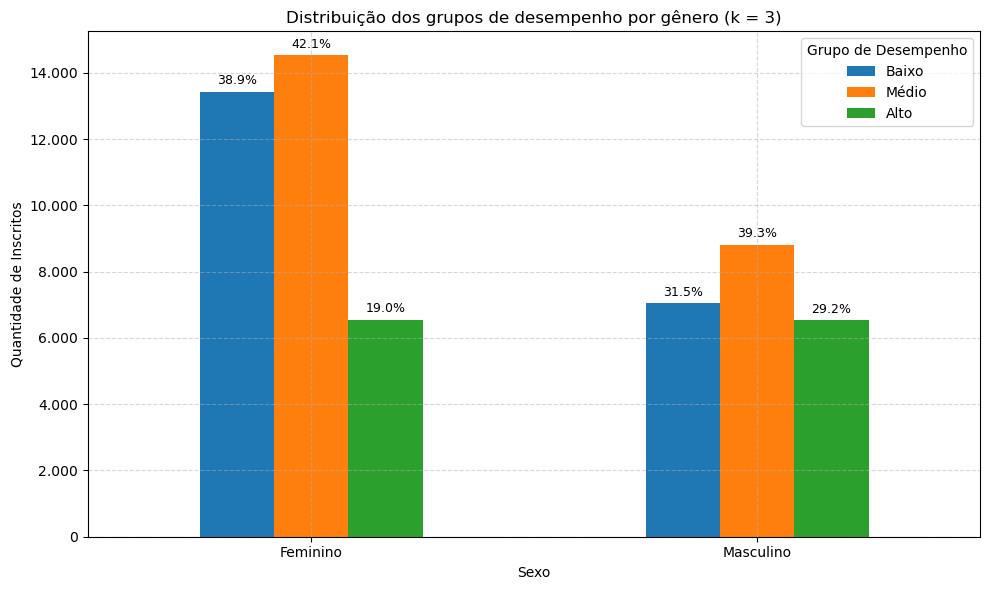

In [17]:
# ============================================================
# 1️⃣ Preparação da base
# ============================================================
colunas = [
    "TP_SEXO",
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = df_ifnmg[colunas].dropna().copy()


# ============================================================
# 2️⃣ Clusterização (k = 3)
# ============================================================
X = notas[
    ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT"]
].values

# Normalização (boa prática)
Xz = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_raw = kmeans.fit_predict(Xz)


# ============================================================
# 3️⃣ Renomeação semântica dos clusters
# ============================================================
centers = kmeans.cluster_centers_
centers_mean = centers.mean(axis=1)

order = np.argsort(centers_mean)  # pior → melhor
old2rank = {old: r for r, old in enumerate(order)}

rank2name = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}

notas["Cluster"] = [rank2name[old2rank[l]] for l in labels_raw]


# ============================================================
# 4️⃣ Contagem por Sexo × Cluster
# ============================================================
contagem = (
    notas
    .groupby(["TP_SEXO", "Cluster"], observed=True)
    .size()
    .reset_index(name="Quantidade")
)

ordem_clusters = ["Baixo", "Médio", "Alto"]

tabela = (
    contagem
    .pivot_table(
        index="TP_SEXO",
        columns="Cluster",
        values="Quantidade",
        aggfunc="sum",
        observed=True
    )
    .reindex(columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 5️⃣ Rótulos de Sexo
# ============================================================
def rotulo_sexo(v):
    return {
        0: "Feminino", 1: "Masculino",
        "0": "Feminino", "1": "Masculino",
        "F": "Feminino", "M": "Masculino"
    }.get(v, str(v))

tabela.index = [rotulo_sexo(i) for i in tabela.index]


# ============================================================
# 6️⃣ Tabela Numérica com Totais
# ============================================================
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)

print("\nTabela — Sexo × Cluster (k = 3):\n")
print(tabela_tot)


# ============================================================
# 7️⃣ Percentuais por Sexo
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 8️⃣ Gráfico
# ============================================================
ax = tabela.plot(kind="bar", figsize=(10, 6))

ax.set_title("Distribuição dos grupos de desempenho por gênero (k = 3)")
ax.set_xlabel("Sexo")
ax.set_ylabel("Quantidade de Inscritos")
ax.legend(title="Grupo de Desempenho")
ax.set_xticklabels(tabela.index, rotation=0)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

ax.grid(True, linestyle="--", alpha=0.5)

# Percentuais sobre as barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()

Entre as estudantes do gênero feminino, observa-se uma maior concentração nos grupos Baixo (38,9%) e Médio (42,1%), enquanto apenas 19,0% atingem o grupo de Alto desempenho.

Já entre os estudantes do gênero masculino, a proporção no grupo de Alto desempenho é mais elevada (29,2%), acompanhada de 31,5% no grupo Baixo e 39,3% no grupo Médio.

Esses resultados indicam que, embora as mulheres representem maior número total de participantes, os homens concentram maior proporção nos níveis mais altos de desempenho.
Por outro lado, o percentual feminino nos grupos Baixo e Médio é mais expressivo, sugerindo uma distribuição menos favorável quanto ao rendimento geral.

Ainda assim, a diferença entre os grupos Médio e Baixo é relativamente pequena, indicando que o desempenho de ambos os gêneros se concentra predominantemente no nível intermediário.

### **Quantidade de inscritos por grupo para cada cor/raça**


Tabela — Raça/Cor × Cluster (k = 3):

Cluster        Baixo  Médio   Alto  Total
Não declarado    275    314    241    830
Branca          3623   5380   4599  13602
Preta           3108   3316   1248   7672
Parda          12811  13718   6773  33302
Amarela          510    515    223   1248
Indígena         169    105     18    292
Total          20496  23348  13102  56946


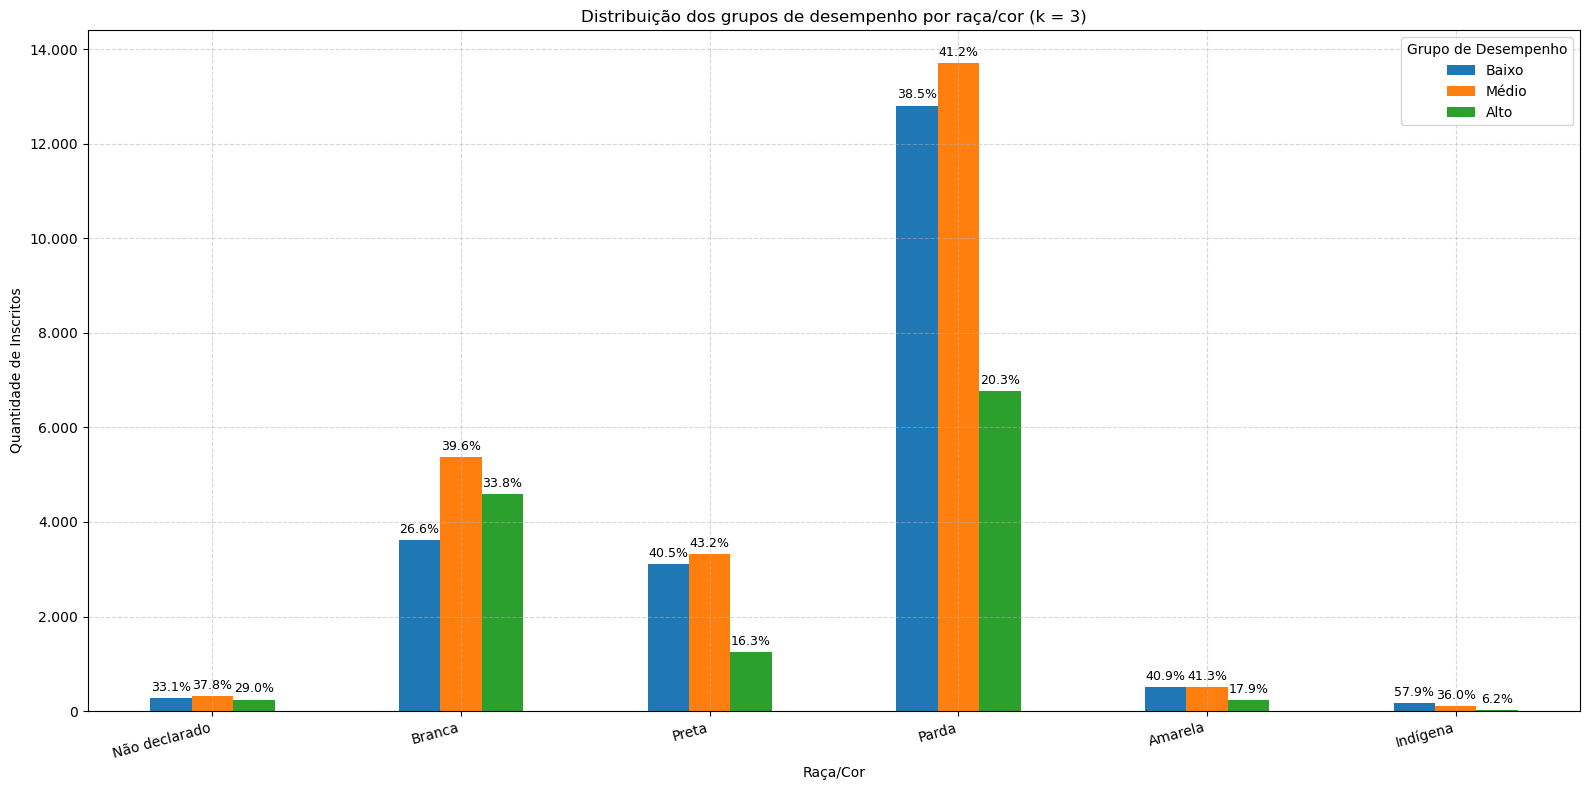

In [18]:
# ============================================================
# 1️⃣ Base de dados
# ============================================================
base = df_ifnmg.copy() if "df_ifnmg" in globals() else df_final.copy()

# Garante a coluna TP_COR_RACA
if "TP_COR_RACA" not in base.columns:
    dummy_cols = [c for c in base.columns if c.startswith("COR_RACA_")]
    if not dummy_cols:
        raise ValueError("Não encontrei TP_COR_RACA nem colunas COR_RACA_* na base.")
    base["TP_COR_RACA"] = (
        base[dummy_cols]
        .idxmax(axis=1)
        .str.replace("COR_RACA_", "", regex=False)
        .astype(int)
    )


# ============================================================
# 2️⃣ Seleção das notas
# ============================================================
cols_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = base[["TP_COR_RACA"] + cols_notas].dropna(subset=cols_notas).copy()


# ============================================================
# 3️⃣ Clusterização (k = 3)
# ============================================================
X = notas[cols_notas].values
Xz = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_raw = kmeans.fit_predict(Xz)

# Renomeação semântica
centers = kmeans.cluster_centers_
order = centers.mean(axis=1).argsort()  # pior → melhor
old2rank = {old: r for r, old in enumerate(order)}

rank2name = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}

notas["Cluster"] = [rank2name[old2rank[l]] for l in labels_raw]


# ============================================================
# 4️⃣ Contagem Raça/Cor × Cluster
# ============================================================
contagem = (
    notas
    .groupby(["TP_COR_RACA", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)

ordem_raca = [0, 1, 2, 3, 4, 5]
ordem_clusters = ["Baixo", "Médio", "Alto"]

tabela = (
    contagem
    .pivot(index="TP_COR_RACA", columns="Cluster", values="Quantidade")
    .reindex(
        index=[r for r in ordem_raca if r in contagem["TP_COR_RACA"].unique()],
        columns=ordem_clusters
    )
    .fillna(0)
    .astype(int)
)


# ============================================================
# 5️⃣ Rótulos de Raça/Cor
# ============================================================
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena"
}

tabela.index = [mapa_raca[i] for i in tabela.index]


# ============================================================
# 6️⃣ Tabela numérica com totais
# ============================================================
tabela_tot = tabela.copy()
tabela_tot["Total"] = tabela_tot.sum(axis=1)
tabela_tot.loc["Total"] = tabela_tot.sum(numeric_only=True)

print("\nTabela — Raça/Cor × Cluster (k = 3):\n")
print(tabela_tot)


# ============================================================
# 7️⃣ Percentuais por Raça/Cor
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 8️⃣ Gráfico
# ============================================================
fig, ax = plt.subplots(figsize=(16, 8))
tabela.plot(kind="bar", ax=ax)

ax.set_title("Distribuição dos grupos de desempenho por raça/cor (k = 3)")
ax.set_xlabel("Raça/Cor")
ax.set_ylabel("Quantidade de Inscritos")
ax.set_xticklabels(tabela.index, rotation=15, ha="right")
ax.legend(title="Grupo de Desempenho")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

ax.grid(True, linestyle="--", alpha=0.5)

# Percentuais sobre as barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

plt.tight_layout()
plt.show()


Os grupos preto e pardo apresentam a maior concentração de participantes nos níveis Baixo e Médio de desempenho.
Entre os estudantes pardos, que representam a maior parcela dos inscritos, quase 80% se concentram nos dois níveis inferiores — 38,5% no grupo Baixo e 41,2% no grupo Médio —, enquanto apenas 20,3% alcançam o grupo Alto.

Um padrão semelhante é observado entre os pretos, com 40,5% no grupo Baixo e 43,2% no grupo Médio. Apenas 16,3% estão entre os desempenhos mais altos, o que reforça a persistência de desigualdades raciais no rendimento escolar.

Os estudantes brancos apresentam uma distribuição mais equilibrada: 26,6% no grupo Baixo, 39,6% no Médio e 33,8% no Alto.
Essa proporção é visivelmente superior à dos grupos preto e pardo no desempenho mais elevado, indicando melhor desempenho médio entre os estudantes brancos.

Já entre os amarelos, observa-se 41,3% no grupo Médio, 40,9% no Baixo e 17,9% no Alto — um padrão semelhante ao dos grupos mais vulneráveis, sugerindo que o tamanho reduzido da amostra pode influenciar a distribuição observada.

O grupo indígena apresenta o desempenho mais concentrado nos níveis baixos, com 57,9% no grupo Baixo e apenas 6,2% no Alto, revelando um quadro de maior desigualdade e vulnerabilidade educacional.
Já os que não declararam raça/cor mostram distribuição mais equilibrada, com leve predominância no grupo Médio (37,8%) e desempenho Alto em 29% dos casos.

### **Quantidade de inscritos por grupo para cada faixa de renda mensal**

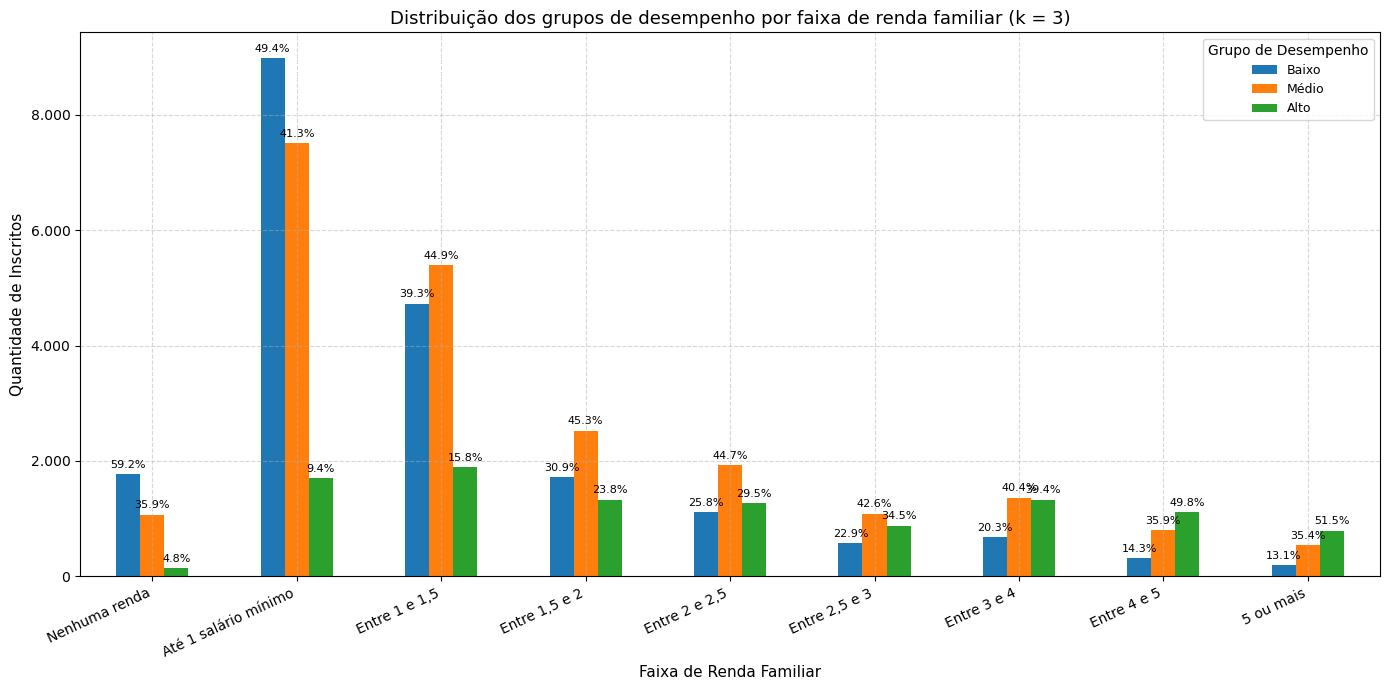

In [19]:
# ============================================================
# 1️⃣ Base de dados
# ============================================================
base = df_ifnmg.copy()

# Garante a coluna RENDA_MENSAL
if "RENDA_MENSAL" not in base.columns:
    renda_dummies = [c for c in base.columns if c.startswith("RENDA_MENSAL_")]
    if not renda_dummies:
        raise ValueError("Não encontrei coluna 'RENDA_MENSAL' nem dummies 'RENDA_MENSAL_*'.")
    base["RENDA_MENSAL"] = (
        base[renda_dummies]
        .idxmax(axis=1)
        .str.replace("RENDA_MENSAL_", "", regex=False)
    )


# ============================================================
# 2️⃣ Seleção das notas
# ============================================================
cols_notas = [
    "NU_NOTA_CN",
    "NU_NOTA_CH",
    "NU_NOTA_LC",
    "NU_NOTA_MT"
]

notas = base[["RENDA_MENSAL"] + cols_notas].dropna(subset=cols_notas).copy()


# ============================================================
# 3️⃣ Clusterização (k = 3)
# ============================================================
X = notas[cols_notas].values
Xz = StandardScaler().fit_transform(X)

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_raw = kmeans.fit_predict(Xz)

# Renomeação semântica
centers = kmeans.cluster_centers_
order = centers.mean(axis=1).argsort()  # pior → melhor
old2rank = {old: r for r, old in enumerate(order)}

rank2name = {
    0: "Baixo",
    1: "Médio",
    2: "Alto"
}

notas["Cluster"] = [rank2name[old2rank[l]] for l in labels_raw]


# ============================================================
# 4️⃣ Faixas de renda (descrições)
# ============================================================
mapa_renda = {
    "A": "Nenhuma renda",
    "B": "Até 1 salário mínimo",
    "C": "Entre 1 e 1,5",
    "D": "Entre 1,5 e 2",
    "E": "Entre 2 e 2,5",
    "F": "Entre 2,5 e 3",
    "G": "Entre 3 e 4",
    "H": "Entre 4 e 5",
    "I": "5 ou mais"
}

notas = notas[notas["RENDA_MENSAL"].isin(mapa_renda.keys())].copy()
notas["Faixa_Renda"] = notas["RENDA_MENSAL"].map(mapa_renda)


# ============================================================
# 5️⃣ Contagem Renda × Cluster
# ============================================================
contagem = (
    notas
    .groupby(["Faixa_Renda", "Cluster"])
    .size()
    .reset_index(name="Quantidade")
)

ordem_renda = [
    "Nenhuma renda",
    "Até 1 salário mínimo",
    "Entre 1 e 1,5",
    "Entre 1,5 e 2",
    "Entre 2 e 2,5",
    "Entre 2,5 e 3",
    "Entre 3 e 4",
    "Entre 4 e 5",
    "5 ou mais"
]

ordem_clusters = ["Baixo", "Médio", "Alto"]

tabela = (
    contagem
    .pivot(index="Faixa_Renda", columns="Cluster", values="Quantidade")
    .reindex(index=ordem_renda, columns=ordem_clusters)
    .fillna(0)
    .astype(int)
)


# ============================================================
# 6️⃣ Percentuais por faixa de renda
# ============================================================
percent = tabela.div(tabela.sum(axis=1), axis=0) * 100


# ============================================================
# 7️⃣ Gráfico
# ============================================================
fig, ax = plt.subplots(figsize=(14, 7))
tabela.plot(kind="bar", ax=ax)

ax.set_title(
    "Distribuição dos grupos de desempenho por faixa de renda familiar (k = 3)",
    fontsize=13
)
ax.set_xlabel("Faixa de Renda Familiar", fontsize=11)
ax.set_ylabel("Quantidade de Inscritos", fontsize=11)
ax.set_xticklabels(tabela.index, rotation=25, ha="right")
ax.legend(title="Grupo de Desempenho", fontsize=9)
ax.grid(True, linestyle="--", alpha=0.5)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda v, _: f"{int(v):,}".replace(",", "."))
)

# Percentuais sobre as barras
for i, container in enumerate(ax.containers):
    col = tabela.columns[i]
    labels = [f"{v:.1f}%" for v in percent[col]]
    ax.bar_label(container, labels=labels, padding=3, fontsize=8)

plt.tight_layout()
plt.show()


Entre os estudantes com nenhuma renda ou até 1 salário mínimo, observa-se forte concentração nos grupos de desempenho Abaixo da Média.
Nessas faixas, mais de 60% dos inscritos estão nesse grupo, enquanto apenas cerca de 10% a 15% alcançam o nível Acima da Média, evidenciando desigualdades expressivas associadas à renda.

Na faixa de até 1,5 salário mínimo, nota-se uma leve melhora: a proporção de alunos Abaixo da Média diminui, enquanto os grupos Média e Acima da Média ganham espaço, indicando um início de ascensão no desempenho conforme aumenta a renda familiar.


Nas faixas intermediárias, o desempenho se distribui de forma mais equilibrada entre os três grupos.
Entre os estudantes com renda de 2 a 2,5 salários mínimos, cerca de 45% estão no grupo Média, 30% no Acima da Média e 25% no Abaixo da Média, mostrando uma melhora significativa em relação às faixas de menor renda.

Esse comportamento sugere que o aumento da renda familiar contribui para uma melhora gradual no desempenho escolar, possivelmente pela ampliação do acesso a recursos educacionais, ambiente de estudo mais adequado e menor vulnerabilidade socioeconômica.


A partir de 3 salários mínimos, o cenário se inverte: o grupo Acima da Média passa a ser predominante.
Entre os alunos com renda de 3 a 4 salários, cerca de 50% estão nesse grupo, e nas faixas acima de 4 salários mínimos, essa proporção ultrapassa 60%, enquanto o grupo Abaixo da Média cai para menos de 20% dos participantes.

Esses resultados evidenciam uma relação direta entre renda e desempenho acadêmico.
Quanto maior a renda familiar, menor a proporção de estudantes nos grupos de baixo desempenho e maior a concentração nos de desempenho elevado.